# RAG System

In [1]:
!pip install -qU langchain-chroma langchain-community langchain-core langchain-text-splitters
!pip install -qU sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.7/508.7 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.0/23.0 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 

In [ ]:
import os
import json
from langchain_community.embeddings import SentenceTransformerEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

print("\nLoading reviews from clean_electronics.json...")
with open('/content/clean_electronics.json', 'r') as f:
    json_data = json.load(f)

reviews_data = [item['text'] for item in json_data if 'text' in item]

documents = [Document(page_content=review) for review in reviews_data]
print(f"Loaded {len(documents)} reviews.")

embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=0)
chunks = text_splitter.split_documents(documents)

vectorstore = Chroma.from_documents(chunks, embeddings)


Loading reviews from clean_electronics.json...
Loaded 13664 reviews.


/tmp/ipykernel_10225/1256428987.py:17: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
question = "How durable is the product?"
similar_reviews = vectorstore.similarity_search(question, k=10)
print(f"\nSimilar reviews for '{question}':")
for i, review in enumerate(similar_reviews):
    print(f"Review {i+1}: {review.page_content}")


Similar reviews for 'How durable is the product?':
Review 1: Great product durable and inexpensive
Review 2: The product is light weight and durable.
Review 3: It’s kinda durable
Review 4: Been using it for six months regularly. Really sturdy, pairs well with bluetooth mice and WiFi.  No major complains other than the lack of backlit keyboard.
Review 5: I've had it for a couple of months now and It's great. Only thing is, it's really heavy so carrying It to school is an issue
Review 6: My son is hard on his things.  And this is durable.
Review 7: lasted for many years.  Buyers Beware this product is of low quality.
Review 8: my son started doing home work on the computer every night... he was using my laptop. A friend's mom said she got one for her kid, was well-priced and had all the features. So, here we are... my son uses it every single day. I have no worries about durability, for the price i am very happy...
Review 9: Had it about 6 months. No problems. Easy to use.
Review 10: Re

## ABSA System

In [ ]:
import json

print("\nLoading reviews from clean_electronics.json...")
with open('/content/clean_electronics.json', 'r') as f:
    json_data = json.load(f)



Loading reviews from clean_electronics.json...


In [ ]:
reviews = {}
for item in json_data:
  if item['parent_asin'] in reviews:
    reviews[item['parent_asin']].append(item['text'])
  else:
    reviews[item['parent_asin']] = [item['text']]

In [ ]:
print(reviews.keys())

dict_keys(['B08BH87FPJ', 'B0C7H1XD7V', 'B09P29VXG1', 'B0B72PYMGX', 'B07GM2J11Q', 'B096JQY4YR', 'B0C2ZMJW53', 'B0BLBY439T', 'B0869L1326', 'B0BBKNHDRH'])


In [ ]:
import torch
from transformers import T5TokenizerFast, AutoModelForSeq2SeqLM

tokenizer = T5TokenizerFast.from_pretrained("whismyswift/t5-absa-2")
model = AutoModelForSeq2SeqLM.from_pretrained("whismyswift/t5-absa-2")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/151 [00:00<?, ?B/s]

In [ ]:
def extract_aspects_and_sentiment(text, model, tokenizer, device, num_beams=4, max_target_length=64):
    model.eval()

    # Updated prefix to match training
    input_text = f"extract aspect and sentiment: {text}"
    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        max_length=128,
        truncation=True,
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=max_target_length,
            num_beams=num_beams,
            early_stopping=True,
        )

    raw_output = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

    # Parse the output: "battery life | positive"
    if "|" in raw_output:
        aspect, sentiment = raw_output.split("|", 1)
        aspect = aspect.strip()
        sentiment = sentiment.strip()
    else:
        # Fallback if model doesn't produce expected format
        aspect = raw_output
        sentiment = "unknown"

    return {"aspect": aspect, "sentiment": sentiment, "raw": raw_output}

In [ ]:
import re

text = "Fantastic we needed it to take camping. So lightweight. Love it I use it at home also. It is a terrific laptop."
sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if s.strip()]
aspects = []
for sentence in sentences:
    result = extract_aspects_and_sentiment(sentence, model, tokenizer, device)
    if result is not None:
        aspects.append(result)
print(aspects)

[{'aspect': 'camping', 'sentiment': 'positive', 'raw': 'camping | positive'}, {'aspect': 'lightweight', 'sentiment': 'positive', 'raw': 'lightweight | positive'}, {'aspect': 'use', 'sentiment': 'positive', 'raw': 'use | positive'}, {'aspect': 'laptop', 'sentiment': 'positive', 'raw': 'laptop | positive'}]


In [ ]:
results = []
for text in reviews:
    predicted_result = extract_aspects_and_sentiment(text, model, tokenizer, device)
    predicted_aspect = predicted_result['aspect']
    predicted_sentiment = predicted_result['sentiment']

    results.append({
        "predicted_aspect": predicted_aspect,
        "predicted_sentiment": predicted_sentiment,
    })

In [ ]:
from sentence_transformers import SentenceTransformer, util
import torch

# 1. Load Model
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Define Core Aspects
core_aspects = [
    "computer",
    "device",
    "battery",
    "display",
    'screen',
    'graphics',
    "performance",
    "usage",
    "price",
    "keyboard",
    "touchpad",
    "audio",
    'size',
    "thickness",
    'color',
    "connectivity",
    "storage",
    "software"
]

# 3. Generate Embeddings for Core Aspects
core_embeddings = model.encode(core_aspects, convert_to_tensor=True)

# 4. Extracted Aspects from Reviews
extracted_terms = []
for result in results:
    extracted_terms.append(result['predicted_aspect'])

# 5. Generate Embeddings for Extracted Terms
term_embeddings = model.encode(extracted_terms, convert_to_tensor=True)

# 6. Map Terms to Core Aspects
mapped_results = []
threshold = 0.4

for i, term in enumerate(extracted_terms):
    # Calculate cosine similarity between this term and all core aspects
    cos_scores = util.cos_sim(term_embeddings[i], core_embeddings)[0]

    # Find the best matching core aspect
    best_score = torch.max(cos_scores)
    best_idx = torch.argmax(cos_scores)

    # Apply Threshold Logic
    if best_score >= threshold:
        assigned_category = core_aspects[best_idx]
        confidence = best_score.item()
    else:
        assigned_category = "Others"
        confidence = best_score.item()

    mapped_results.append({
        "original_term": term,
        "mapped_aspect": assigned_category,
        "similarity_score": round(confidence, 3)
    })

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

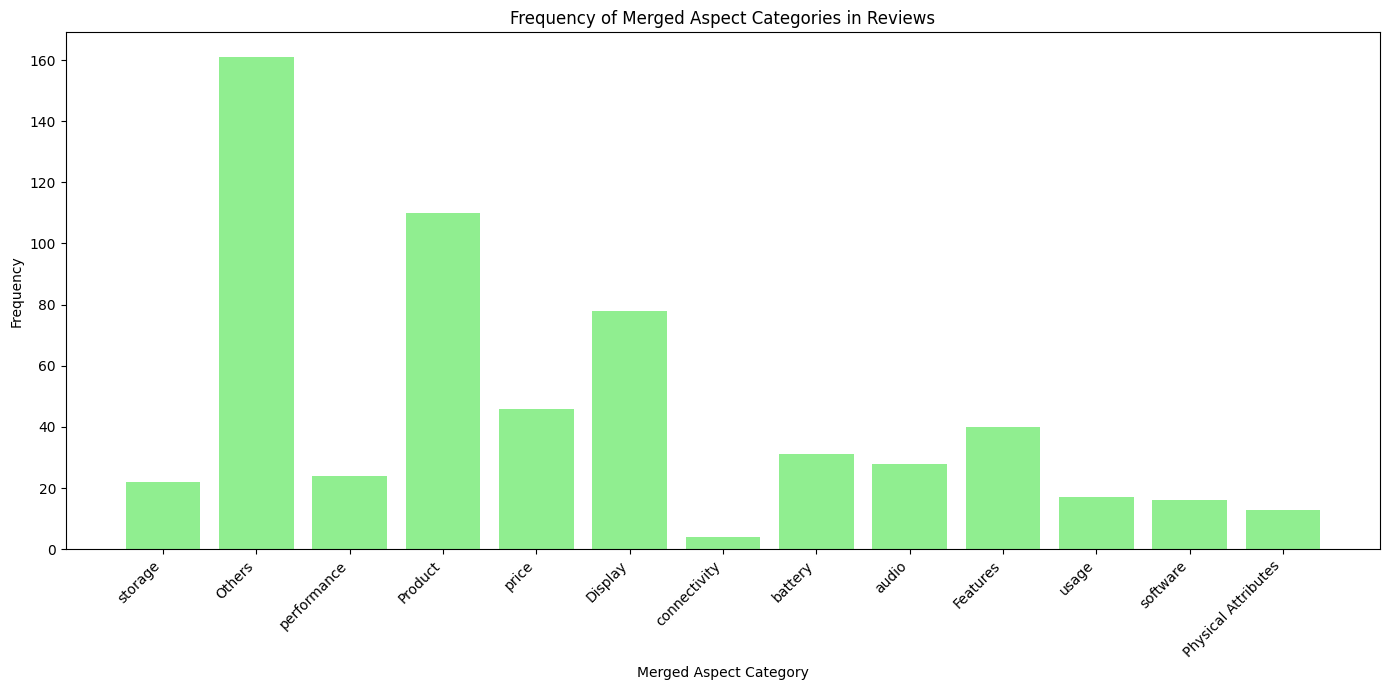

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Define the mapping for merging categories
category_merger = {
    'color': 'Physical Attributes',
    'thickness': 'Physical Attributes',
    'size': 'Physical Attributes',
    'display': 'Display',
    'screen': 'Display',
    'graphics': 'Display',
    'device': 'Product',
    'computer': 'Product',
    'keyboard': 'Features',
    'touchpad': 'Features',
}

merged_mapped_results = []

for item in mapped_results:
    original_aspect = item['mapped_aspect']
    # Apply the merger, if a mapping exists, otherwise keep the original aspect
    merged_aspect = category_merger.get(original_aspect, original_aspect)

    merged_mapped_results.append({
        "original_term": item["original_term"],
        "mapped_aspect": merged_aspect,
        "similarity_score": item["similarity_score"]
    })

# Extract all merged aspects
all_merged_aspects = [item['mapped_aspect'] for item in merged_mapped_results]

# Count occurrences of each merged aspect
aspect_counts_merged = Counter(all_merged_aspects)

# Prepare data for plotting
aspect_labels_merged = list(aspect_counts_merged.keys())
aspect_frequencies_merged = list(aspect_counts_merged.values())

# Create the bar chart for merged categories
plt.figure(figsize=(14, 7))
plt.bar(aspect_labels_merged, aspect_frequencies_merged, color='lightgreen')
plt.xlabel('Merged Aspect Category')
plt.ylabel('Frequency')
plt.title('Frequency of Merged Aspect Categories in Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

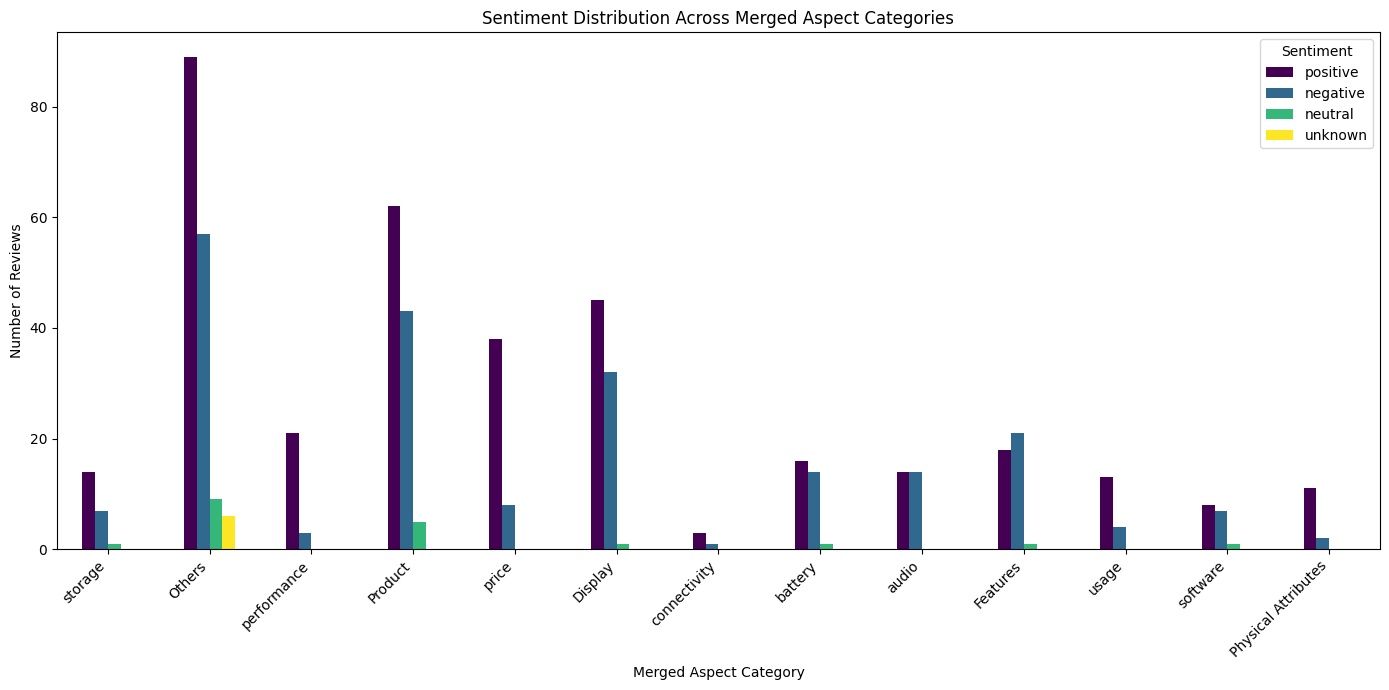

Sentiment counts by category:
                     positive  negative  neutral  unknown
storage                    14         7        1        0
Others                     89        57        9        6
performance                21         3        0        0
Product                    62        43        5        0
price                      38         8        0        0
Display                    45        32        1        0
connectivity                3         1        0        0
battery                    16        14        1        0
audio                      14        14        0        0
Features                   18        21        1        0
usage                      13         4        0        0
software                    8         7        1        0
Physical Attributes        11         2        0        0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

sentiment_counts_by_category = {}

for i in range(len(merged_mapped_results)):
    category = merged_mapped_results[i]['mapped_aspect']
    sentiment = results[i]['predicted_sentiment']

    if category not in sentiment_counts_by_category:
        sentiment_counts_by_category[category] = {'positive': 0, 'negative': 0, 'neutral': 0, 'unknown': 0}

    if sentiment in sentiment_counts_by_category[category]:
        sentiment_counts_by_category[category][sentiment] += 1
    else:
        sentiment_counts_by_category[category]['unknown'] += 1

df_sentiment = pd.DataFrame(sentiment_counts_by_category).T
df_sentiment = df_sentiment.fillna(0)

# Ensure all sentiment columns exist, even if all zeros
for sent_type in ['positive', 'negative', 'neutral', 'unknown']:
    if sent_type not in df_sentiment.columns:
        df_sentiment[sent_type] = 0

# Reorder columns to ensure consistent plotting
df_sentiment = df_sentiment[['positive', 'negative', 'neutral', 'unknown']]

# Plotting
df_sentiment.plot(kind='bar', stacked=False, figsize=(14, 7), colormap='viridis')
plt.title('Sentiment Distribution Across Merged Aspect Categories')
plt.xlabel('Merged Aspect Category')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

print("Sentiment counts by category:")
print(df_sentiment)

## Benchmark without Aspect Term Extraction

In [ ]:
# Generate Embeddings for Reviews
term_embeddings = model.encode(reviews['B0BLBY439T'], convert_to_tensor=True)

# Map Terms to Core Aspects
mapped_results_whole = []
threshold = 0.4

for i, term in enumerate(extracted_terms):
    # Calculate cosine similarity between this term and all core aspects
    cos_scores = util.cos_sim(term_embeddings[i], core_embeddings)[0]

    # Find the best matching core aspect
    best_score = torch.max(cos_scores)
    best_idx = torch.argmax(cos_scores)

    # Apply Threshold Logic
    if best_score >= threshold:
        assigned_category = core_aspects[best_idx]
        confidence = best_score.item()
    else:
        assigned_category = "Other/Noise"
        confidence = best_score.item()

    mapped_results_whole.append({
        "original_term": term,
        "mapped_aspect": assigned_category,
        "similarity_score": round(confidence, 3)
    })

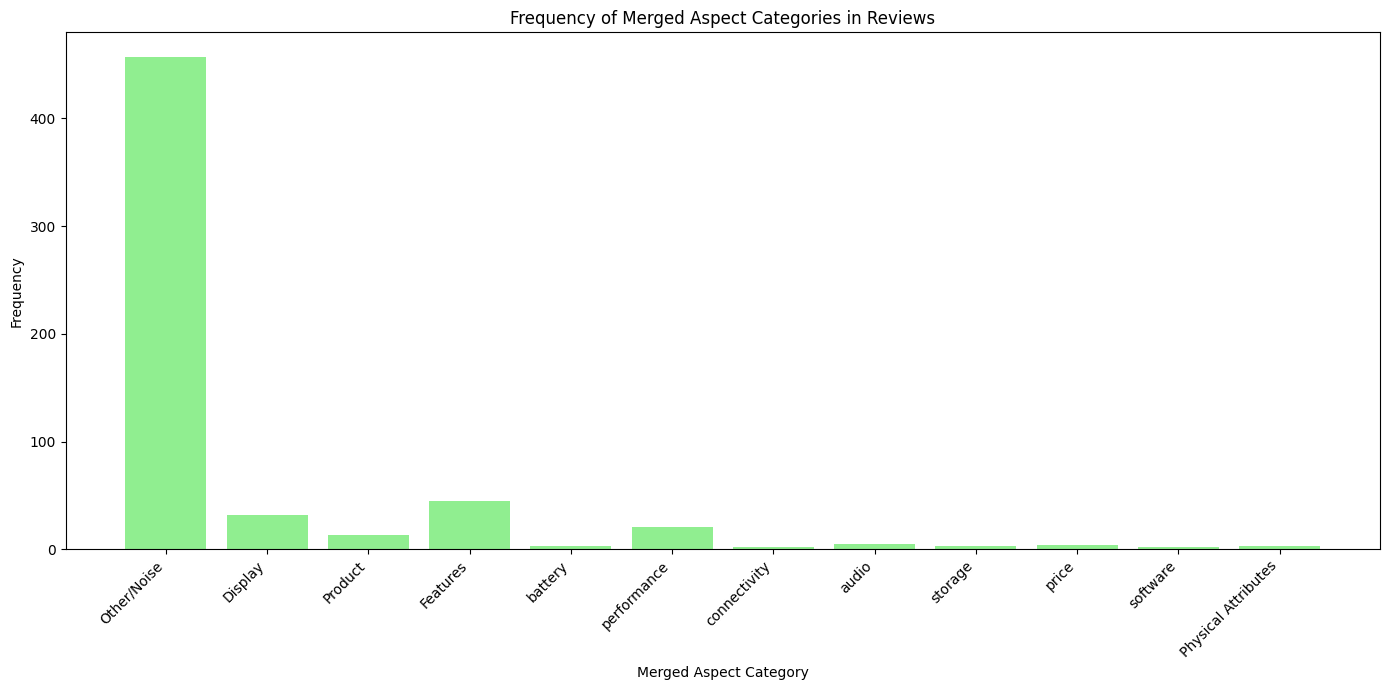

In [ ]:
merged_mapped_results2 = []

for item in mapped_results_whole:
    original_aspect = item['mapped_aspect']
    # Apply the merger, if a mapping exists, otherwise keep the original aspect
    merged_aspect = category_merger.get(original_aspect, original_aspect)

    merged_mapped_results2.append({
        "original_term": item["original_term"],
        "mapped_aspect": merged_aspect,
        "similarity_score": item["similarity_score"]
    })

# Extract all merged aspects
all_merged_aspects = [item['mapped_aspect'] for item in merged_mapped_results2]

# Count occurrences of each merged aspect
aspect_counts_merged = Counter(all_merged_aspects)

# Prepare data for plotting
aspect_labels_merged = list(aspect_counts_merged.keys())
aspect_frequencies_merged = list(aspect_counts_merged.values())

# Create the bar chart for merged categories
plt.figure(figsize=(14, 7))
plt.bar(aspect_labels_merged, aspect_frequencies_merged, color='lightgreen')
plt.xlabel('Merged Aspect Category')
plt.ylabel('Frequency')
plt.title('Frequency of Merged Aspect Categories in Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Summary System

In [ ]:
question = "How is the battery life?"
similar_reviews = vectorstore.similarity_search(question, k=5)

In [ ]:
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("whismyswift/BART_Summary")
model = AutoModelForSeq2SeqLM.from_pretrained("whismyswift/BART_Summary", dtype="auto")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/156 [00:00<?, ?it/s]

In [ ]:
max_input_length = 584
max_target_length = 128

sample_input = {
    "question": question,
    "reviews_input": [similar_reviews[0].page_content,
                      similar_reviews[1].page_content,
                      similar_reviews[2].page_content,
                      similar_reviews[3].page_content,
                      similar_reviews[4].page_content]
}

# Preprocess the sample input
def preprocess_single_example(example):
    instruction = "Summarize customer reviews about the specific aspect mentioned in the query."
    r_processed = " ".join(example['reviews_input']) if isinstance(example['reviews_input'], list) else str(example['reviews_input'])
    input_text = f"instruction: {instruction} Query: {example['question']} Reviews: {r_processed}"
    model_inputs = tokenizer(input_text, max_length=max_input_length, truncation=True, return_tensors="pt")
    return model_inputs

processed_sample = preprocess_single_example(sample_input)

# Move to GPU if available
input_ids = processed_sample['input_ids'].to(model.device)
attention_mask = processed_sample['attention_mask'].to(model.device)

# Generate summary
model.eval()
with torch.no_grad():
    generated_ids = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_length=max_target_length,
        num_beams=4,
        early_stopping=True
    )

print(f"Raw Generated IDs: {generated_ids}")

decoded_summary_with_special_tokens = tokenizer.decode(generated_ids[0], skip_special_tokens=False)
print(f"Decoded Summary (with special tokens): {decoded_summary_with_special_tokens}")

decoded_summary = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

print(f"Question: {sample_input['question']}")
print(f"Reviews: {sample_input['reviews_input']}")
print(f"\nGenerated Summary: {decoded_summary}")

Raw Generated IDs: tensor([[   2,    0,  133, 6173,   32, 3489, 1313, 2624,    5, 3822,  301,    4,
            2]])
Decoded Summary (with special tokens): </s><s>The reviews are generally positive regarding the battery life.</s>
Question: How is the battery life?
Reviews: ['Easy to use long battery life', 'Good battery life and quick', 'Battery life is terrible.', 'battery life. other then that, everything is great.', 'Wonderful battery life. Would highly recommend.']

Generated Summary: The reviews are generally positive regarding the battery life.


## Whole System

In [1]:
import json
import re
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, T5TokenizerFast
from langchain_community.embeddings import SentenceTransformerEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sklearn.cluster import AgglomerativeClustering
from sentence_transformers import SentenceTransformer

max_input_length = 584
max_target_length = 128

# ──────────────────────────────────────────────
# 1. Load reviews from local JSON
# ──────────────────────────────────────────────
PRODUCT_NAMES = {
    "B0C2ZMJW53": "Acer Aspire 3 Slim Laptop",
    "B09P29VXG1": "SAMSUNG Galaxy Tab A8 10.5 Android Tablet",
    "B096JQY4YR": "HP Chromebook 14-inch HD Touchscreen Laptop",
    "B0869L1326": "ASUS VivoBook 15 Thin and Light Laptop",
    "B0BBKNHDRH": "Acer Nitro 5 Gaming Laptop",
    "B08BH87FPJ": "Lenovo Tab M10 Plus Tablet",
    "B0BLBY439T": "Acer Aspire 5 A515-46-R14K Slim Laptop",
    "B0C7H1XD7V": "Lenovo Flex 5 14 2-in-1 Laptop",
    "B07GM2J11Q": "Lenovo Chromebook C330 2-in-1 Convertible Laptop",
    "B0B72PYMGX": "Lenovo IdeaPad 3 11 Chromebook Laptop"
}

with open("clean_electronics.json", "r") as f:
    DATA = json.load(f)

PRODUCTS = {}

for item in DATA:
    product_id = item.get("parent_asin")
    if product_id in PRODUCTS:
        PRODUCTS[product_id].append(item['text'])
    else:
        PRODUCTS[product_id] = [item['text']]

# ──────────────────────────────────────────────
# 2. Build RAG vectorstores
# ──────────────────────────────────────────────

embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=0)

all_documents = []
for product_id, reviews in PRODUCTS.items():
    documents = [
        Document(
            page_content=r,
            metadata={"product": product_id}
        )
        for r in reviews
    ]
    all_documents.extend(documents)

chunks = text_splitter.split_documents(all_documents)
vectorstore = Chroma.from_documents(chunks, embeddings)

print(f"Vectorstore ready")

# ──────────────────────────────────────────────
# 3. Load models
# ──────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading BART model ...")
tokenizer = AutoTokenizer.from_pretrained("whismyswift/BART_Summary")
model = AutoModelForSeq2SeqLM.from_pretrained("whismyswift/BART_Summary", dtype="auto")
model = model.to(device)

print("Loading T5 model ...")
T5_tokenizer = T5TokenizerFast.from_pretrained("whismyswift/t5-absa-2")
T5_model = AutoModelForSeq2SeqLM.from_pretrained("whismyswift/t5-absa-2")
T5_model = T5_model.to(device)

# Define a separate SentenceTransformer for direct encoding
print("Loading SentenceTransformer for aspect clustering ...")
aspect_embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

print(f"Models loaded.")


/tmp/ipykernel_4812/3977491810.py:47: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vectorstore ready
Loading BART model ...


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading SentenceTransformer for aspect clustering ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models loaded.


In [5]:
from collections import defaultdict

# ──────────────────────────────────────────────
# 4. Build context string from reviews
# ──────────────────────────────────────────────

def preprocess_single_example(example):
    instruction = "Summarize customer reviews about the specific aspect mentioned in the query."
    r_processed = " ".join(example['reviews_input']) if isinstance(example['reviews_input'], list) else str(example['reviews_input'])
    input_text = f"instruction: {instruction} Query: {example['question']} Reviews: {r_processed}"
    model_inputs = tokenizer(input_text, max_length=max_input_length, truncation=True, return_tensors="pt")
    return model_inputs

# ──────────────────────────────────────────────
# 5. Aspect Based Sentiment Analysis Extraction
# ──────────────────────────────────────────────

def extract_aspects_and_sentiment(text, model, tokenizer, device, num_beams=4, max_target_length=64):
    model.eval()

    # Updated prefix to match training
    input_text = f"extract aspect and sentiment: {text}"
    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        max_length=128,
        truncation=True,
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=max_target_length,
            num_beams=num_beams,
            early_stopping=True
        )

    raw_output = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

    # Parse the output: "battery life | positive"
    if "|" in raw_output:
        aspect, sentiment = raw_output.split("|", 1)
        aspect = aspect.strip()
        sentiment = sentiment.strip()
    else:
        return None

    return {"aspect": aspect, "sentiment": sentiment}


def chat(message, product_name):
    if not product_name:
        return "No Product Selected"

    results = vectorstore.similarity_search_with_score(message, k=5, filter={"product": product_name})
    similar_reviews = [doc for doc, score in results if score < 1.0]

    if not similar_reviews:
        return "No Reviews Found"

    absa_per_review = []
    aspects_list = []
    sentiments_list = []
    similar_reviews_with_aspect = []
    for r in similar_reviews:
        sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', r.page_content) if s.strip()]
        aspects = []
        for sentence in sentences:
            result = extract_aspects_and_sentiment(sentence, T5_model, T5_tokenizer, device)
            if result is not None:
                aspects.append(result)
        absa_per_review.append(aspects)
        reviews_with_aspect = r.page_content + " Aspects: "
        for i in aspects:
            reviews_with_aspect += "(" + i['aspect'] + ": " + i['sentiment'] + ")"
            aspects_list.append(i['aspect'])
            sentiments_list.append(i['sentiment'])
        similar_reviews_with_aspect.append(reviews_with_aspect)

    sample_input = {
        "question": message,
        "reviews_input": similar_reviews_with_aspect
    }

    processed_sample = preprocess_single_example(sample_input)

    # Move to GPU if available
    input_ids = processed_sample['input_ids'].to(model.device)
    attention_mask = processed_sample['attention_mask'].to(model.device)

    # Generate summary
    model.eval()
    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_length=max_target_length,
            num_beams=4,
            early_stopping=True
        )

    decoded_summary = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

    if aspects_list:
      aspect_embeddings = aspect_embedding_model.encode(aspects_list)

      clustering = AgglomerativeClustering(
          n_clusters=None,
          distance_threshold=0.15,
          metric="cosine",
          linkage="average"
      )
      labels = clustering.fit_predict(aspect_embeddings)

      # group and count sentiments per cluster
      clusters = defaultdict(lambda: {"members": [], "positive": 0, "negative": 0, "neutral": 0})
      for aspect, label, absa in zip(aspects_list, labels, sentiments_list):
          clusters[label]["members"].append(aspect)
          sentiment = absa.lower()
          if sentiment in clusters[label]:
              clusters[label][sentiment] += 1

      cluster_summary_lines = []
      for label, info in clusters.items():
          representative = min(info["members"], key=len)
          total = info["positive"] + info["negative"] + info["neutral"]
          cluster_summary_lines.append(
              f"{representative}: +{info['positive']} -{info['negative']} ~{info['neutral']} ({total} mentions)"
          )

      cluster_summary_text = "\n".join(cluster_summary_lines)


    reviews_text = []
    for i, (r, aspects) in enumerate(zip(similar_reviews, absa_per_review)):
        review_line = f"**Review {i+1}:** {r.page_content}"
        if aspects:
            aspects_line = " | ".join(f"{a['aspect']} ({a['sentiment']})" for a in aspects)
            review_line += f"  \n*Aspects: {aspects_line}*"
        reviews_text.append(review_line)

    response = (
        f"**Summary:**\n{decoded_summary}\n\n"
        f"---\n\n"
        f"**Aspect Sentiment Counts:**\n{cluster_summary_text}\n\n"
        f"---\n\n"
        f"**Retrieved Reviews:**\n\n" + "\n\n".join(reviews_text)
    )

    return response

chat("How is the product battery?", "B0C2ZMJW53")

'**Summary:**\nThe reviews are mixed regarding the product\'s battery life and performance. While some users praise the product for its battery life, others express disappointment regarding the battery\'s poor performance.\n\n---\n\n**Aspect Sentiment Counts:**\ndescribed: +0 -1 ~0 (1 mentions)\nbattery performance: +0 -1 ~0 (1 mentions)\nproduct: +1 -0 ~0 (1 mentions)\nbattery life: +1 -2 ~0 (3 mentions)\ntry: +0 -1 ~0 (1 mentions)\ndisplay: +1 -0 ~0 (1 mentions)\nbrightness: +0 -1 ~0 (1 mentions)\nboot up: +0 -1 ~0 (1 mentions)\nbalanced mode: +1 -0 ~0 (1 mentions)\nprice: +1 -0 ~0 (1 mentions)\n\n---\n\n**Retrieved Reviews:**\n\n**Review 1:** Not good as described. Not hapoy with battery performance.  \n*Aspects: described (negative) | battery performance (negative)*\n\n**Review 2:** Excellent product. Battery life is not perfect but that is minor to the advantages.  \n*Aspects: product (positive) | battery life (negative)*\n\n**Review 3:** great battery life and display  \n*Aspects